# EDA - Tipologija zgrada Novog Sada

Kratka eksplorativna analiza *pre* modelovanja: zgrade, atributi i korelacije među atributima (motivacija za redukciju dimenzionalnosti). Dobijeni tipovi i mape su u [`results.ipynb`](results.ipynb).

Pokrenuti nakon `features` (potreban je `data/features_building.parquet`); ne zavisi od klasterovanja.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from scripts import config
plt.rcParams['figure.figsize'] = (8, 4)

## Zgrade (Overture otisci)

broj zgrada: 103873


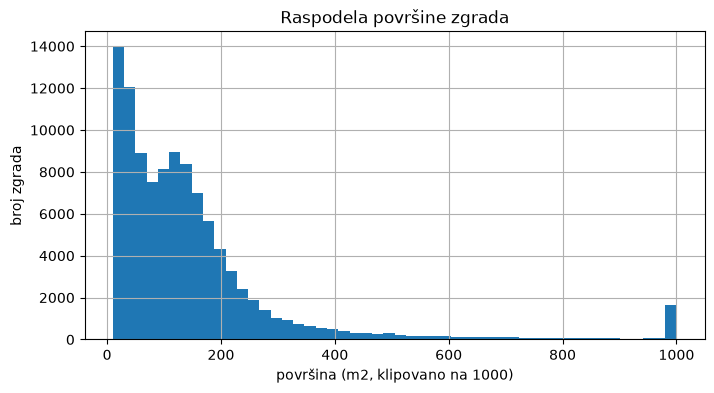

In [2]:
b = gpd.read_parquet(config.FOOTPRINTS_PARQUET)
print('broj zgrada:', len(b))
b['area_m2'].clip(upper=1000).hist(bins=50)
plt.xlabel('površina (m2, klipovano na 1000)'); plt.ylabel('broj zgrada')
plt.title('Raspodela površine zgrada'); plt.show()

## Atributi po zgradi

In [3]:
f = gpd.read_parquet(os.path.join(config.DATA, 'features_building.parquet')).drop(columns='geometry')
FEAT = [c for c in f.columns if c not in ('bid', 'class', 'subtype') and f[c].dtype.kind in 'fi']
print(len(FEAT), 'atributa')
f[FEAT].describe().T[['mean', 'std', 'min', 'max']].round(2)

21 atributa


,mean,std,min,max
area_m2,173.78,528.82,10.00,43902.02
perimeter,50.30,40.23,12.10,1529.34
compactness,0.68,0.12,0.06,1.00
floors,1.07,0.70,1.00,57.00
nn_dist,17.34,23.13,1.98,1618.95
n_within_50m,11.79,6.54,0.00,68.00
ndvi,0.42,0.10,-0.24,0.85
ndbi,-0.02,0.07,-0.41,0.13
dist_grocery,514.14,553.88,0.00,7173.90
dist_school,846.95,765.10,0.00,7322.19


## Korelacije atributa
Mnogi atributi su jako korelisani (npr. spektralni indeksi, POI mere) - to upravo motiviše **redukciju dimenzionalnosti (PCA)** pre klasterovanja.

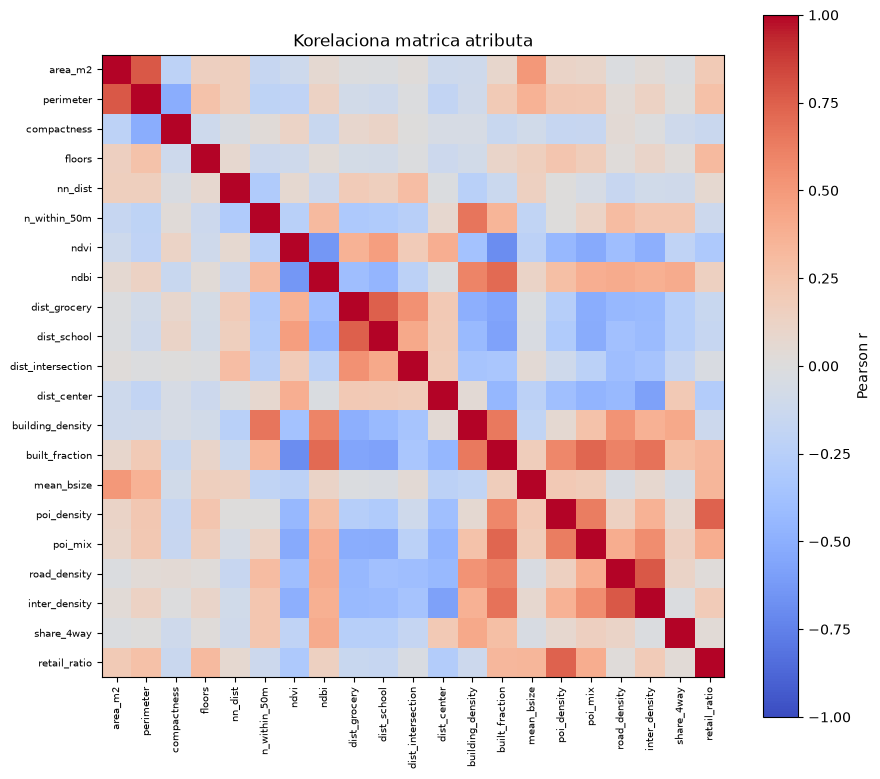

In [4]:
corr = f[FEAT].corr()
plt.figure(figsize=(9, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(FEAT)), FEAT, rotation=90, fontsize=7)
plt.yticks(range(len(FEAT)), FEAT, fontsize=7)
plt.colorbar(label='Pearson r'); plt.title('Korelaciona matrica atributa')
plt.tight_layout(); plt.show()